In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, opes_config, data, adam_hash, hash_configs
import json
from matplotlib.collections import LineCollection

In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
if data["dn"].lower() == "dayu19a":
    true_sample = np.load(base_path / "inputdata_260219A" / "true_sample.npy")
elif data["dn"].lower() == "dayu19b":
    true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
if data["dn"].lower() == "dayu19c":
    true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable_test
dayu19c
[ 4.98277892  6.51347223  2.76207427  3.19690067  3.54080319  0.94804504
  6.74581444  1.63996188 12.3990509   3.05494582  8.80066134  4.99430002
  9.15437894  4.94778008  7.08068876  4.12135903  4.02463831 13.28125697
  1.76219592  4.61739852  1.37239109  3.96623682  5.09954745 18.10005302
  1.70004875  7.12939091 16.69199057  2.513807    7.80731716  2.78369924
  5.7848052   6.41148595  6.12185524  2.45222445  5.17258369  7.89881748
  9.8841552   3.96771935  8.40136594  6.6301936  35.64288019 16.65701048
 14.26115043  2.19983533  2.77204331 12.78248996  4.26802744 22.16974038
  5.99045026  4.62979017]
[1983.         1973.03444217 1960.00749771 1954.48334916 1948.08954782
 1941.00794143 1939.11185135 1925.62022246 1922.3402987  1897.5421969
 1891.43230526 1873.83098257 1863.84238253 1845.53362466 1835.63806449
 1821.47668696 1813.23396889 1805.18469227 1778.62217833 1

In [3]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [4]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 100000
# adam_hash_ee = hash_configs(adam_config_ee, data)

adam_dir = base_dir / f"output/{data["dn"]}/sd_{opes_config["hmcc"]["sd"]}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

np.random.seed(opes_config["hmcc"]["sd"])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (opes_config["hmcc"]["nch"], data["N"]))
# d18o_energies = np.load(adam_dir_ee / "adam_d18o_energies.npy")
# print(np.min(d18o_energies))
# sp_adams = np.load(adam_dir_ee / "adam_samples.npy")

opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
opes_config["df"] = 140 * (opes_config["bs"] - 1)
print(opes_config["df"][-1])
opes_config["dfn"] = np.exp(-opes_config["df"])*opes_config["dfd"]

opes_hash = hash_configs(opes_config, data)
output_dir = adam_dir / f"{opes_hash}"

hmc_config = opes_config["hmcc"]

-133.0


In [5]:
# base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 100000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/sd_{opes_config["hmcc"]["sd"]}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# np.random.seed(opes_config["hmcc"]["sd"])
# sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (opes_config["hmcc"]["nch"], data["N"]))
# d18o_energies = np.load(adam_dir_ee / "adam_d18o_energies.npy")
# print(np.min(d18o_energies))
# sp_adams = np.load(adam_dir_ee / "adam_samples.npy")

# opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
# opes_config["df"] = 140 * (opes_config["bs"] - 1)
# print(opes_config["df"][-1])
# opes_config["dfn"] = np.exp(-opes_config["df"])*opes_config["dfd"]

# opes_hash = hash_configs(opes_config, data)
# output_dir = adam_dir / f"{opes_hash}"

# hmc_config = opes_config["hmcc"]

In [6]:
print(output_dir)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable_test\output\dayu19C\sd_10000\4b0fa932ad


In [12]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

In [8]:

# cumulative_sums = np.cumsum(sp_adams, axis=1) * data["dc"]
# zeros = np.zeros((*sp_adams.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(sp_adams)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# # plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
# plt.show()

In [9]:

# cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
# zeros = np.zeros((*sp.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(sp)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
# plt.show()

In [10]:
base_dir = Path.cwd()

df = np.load(f"{output_dir}/df.npy")
print(df.shape)

(5, 1000, 40)


In [14]:
print(df)

[[[1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  ...
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]]

 [[1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947680e+60 5.76987086e+60]
  ...
  [1.00000000e+03 3.12965282e+07 4.55623565e+11 ... 1.80445068e+60
   3.29947

C:\Users\hanna\AppData\Local\Temp\ipykernel_5852\3098380069.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


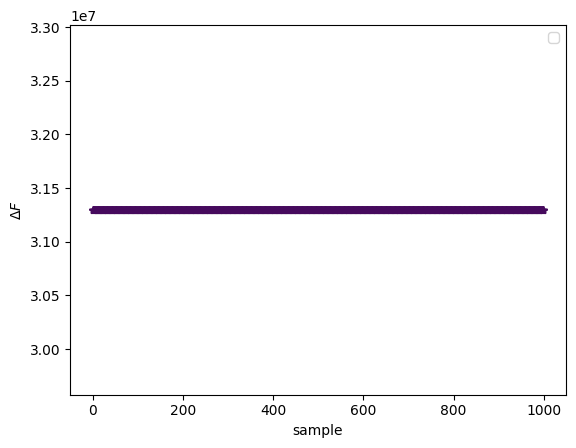

In [20]:
fig, ax = plt.subplots()
ind = 1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, ind])
ax.plot(x[:], sample_delta_F[:], '*-', color = temp_colors[1])
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


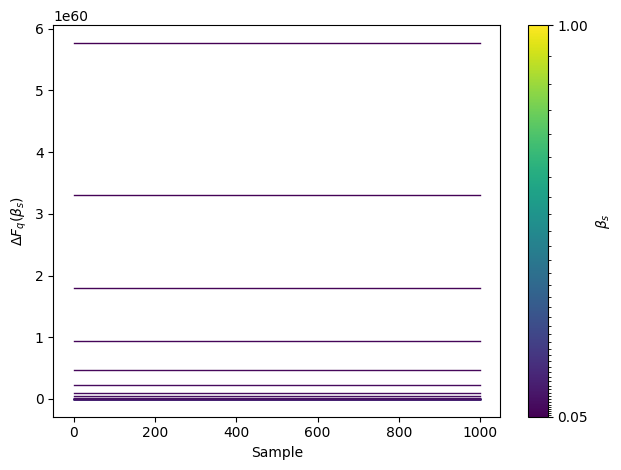

In [18]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(10,opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], sample_delta_F[:], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"Sample")
plt.ylabel(r"$\Delta F_q(\beta_s)$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
plt.savefig(f"{output_dir}/df.jpg")
plt.show()


In [13]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(opes_config["bs"], df[i, -1, :], marker = '*', color = "green")

# plt.savefig(f"{output_dir}/df_to_beta.jpg")
# plt.show()

# # other_df = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/python/src/age_depth_models/age_depth_model_OPES_normal_clean_d18o_stable/output/{data['dn']}/sd_{42}/fb797e5f6c/df.npy")
# other_opes_config = opes_config
# other_opes_config["hmcc"]["sd"] = 10
# other_opes_hash = hash_configs(other_opes_config, data)
# other_df = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/python/src/age_depth_models/age_depth_model_OPES_normal_clean_d18o_stable/output/{data['dn']}/sd_{10}/{other_opes_hash}/df.npy")

# plt.figure()
# plt.plot(opes_config["bs"], df[0, -1, :] - other_df[0, -1, :], marker = '*', color = "green")

# plt.savefig(f"{output_dir}/df_to_beta_compare.jpg")
# plt.show()

In [14]:
# del df, other_df
# gc.collect()

In [15]:
cutout = 10000
bias_values = np.load(f"{output_dir}/bias.npy")[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy")[:, cutout:]


In [16]:
neff = np.sum(np.exp(bias_values[:, cutout:]), axis = 1)**2 / np.sum(np.exp(bias_values[:, cutout:])**2, axis = 1)
print(neff)

[97847.66362957 92509.9967046  92165.95683679 88799.50669394
 87529.12638856]


In [17]:
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     ax.hist(energy_values[i, cutout:], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
# plt.legend()
# plt.savefig(f"{output_dir}/energy_hist.jpg")
# plt.show()   

In [18]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), bias_values[i, cutout:100000], color = colors[i], alpha = 0.5, label = f"Chain {i}")
#     plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), energy_values[i, cutout:100000], color = colors[i], alpha = 0.5)
# plt.xlabel("Sample")
# plt.ylabel("Bias                      Energy")
# plt.legend()
# plt.savefig(f"{output_dir}/energy_and_bias.jpg")
# plt.show()

In [19]:
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

In [20]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(np.linspace(cutout, len(bias_values[0, :]), len(bias_values[i, cutout:])), bias_values[i, cutout:], color = colors[i])
#     plt.plot(np.linspace(cutout, len(bias_values[0, :]), len(bias_values[i, cutout:])), d18o_energy_values[i,cutout:], color = colors[i])
# plt.savefig(f"{output_dir}/d18o_energy_and_bias.jpg")
# plt.show()
# print(np.min(d18o_energy_values))

In [21]:
# print("Reweighting energies for each temp\n")
# temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

# # Compute betas

# # Initial beta
# energy_samples = []
# all_weights = []

# for j in range(opes_config["nt"]):
#     temp_energy_samples = []
#     weights = np.exp(-(opes_config["bs"][j] - 1) * d18o_energy_values + bias_values)
#     for i in range(hmc_config["nch"]):
#             weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
#             indices = np.random.choice(
#                 np.arange(cutout, len(weights_i) + cutout),
#                 size=int(len(weights_i)),
#                 replace=True,
#                 p=weights_i,
#             )
#             temp_energy_samples.append(energy_values[i, indices])

#     print(f"Temp {j} done resampling")
#     all_weights.append(weights)
#     energy_samples.append(temp_energy_samples)

# del indices, temp_energy_samples, d18o_energy_values
# gc.collect()
# energy_samples = np.array(energy_samples)

In [22]:
# all_weights = np.array(all_weights)
# n_eff = np.sum(all_weights, axis = 2)**2 / np.sum(all_weights**2, axis = 2)
# plt.figure()
# plt.plot(opes_config["bs"], n_eff / hmc_config["ns"])
# plt.show()

# del all_weights, n_eff
# gc.collect()


In [23]:
# limit_grid = np.linspace(80, 190, 100)
# bin_grid = limit_grid[:-1]
# mean_energies = np.zeros((hmc_config["nch"], opes_config["nt"]))
# energy_stds = np.zeros((hmc_config["nch"], opes_config["nt"]))

# for k in range(hmc_config["nch"]):
#     fig, ax = plt.subplots(figsize=(6, 4))
#     for j in range(opes_config["nt"]):
#         ax.hist(energy_samples[j, k], bins = 100, color = temp_colors[j], label = f"temp {opes_config["bs"][j]}", alpha = 0.5, density = True)
#         mean_energies[k,j]  = np.mean(energy_samples[j, k])
#         energy_stds[k,j]  = np.std(energy_samples[j, k])
    
#     plt.savefig(f"{output_dir}/temp_pic_chain_{k}.jpg")
#     plt.show()

# del energy_samples, mean_energies, energy_stds, energy_values
# gc.collect()

In [24]:
samples = np.load(output_dir / "samples.npy")[:, cutout:, :]

In [25]:
# # Print R_hat and N_eff using arviz
# idata = az.convert_to_inference_data(samples)
# summary = az.summary(idata, round_to=2)
# print(summary)
# del summary, idata
# gc.collect()

In [26]:
resampled_samples = [] # ändra här..., varför inte omsampla till  rätt storlek direkt?
weights = np.exp(bias_values)
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=int(neff[i]),
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

del bias_values
gc.collect()

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling


2831

In [27]:
# short_samples = samples[:, cutout::10, :]
# del samples
# gc.collect()
# short_resampled_samples = resampled_samples[:, :, :]
# del resampled_samples
# gc.collect()

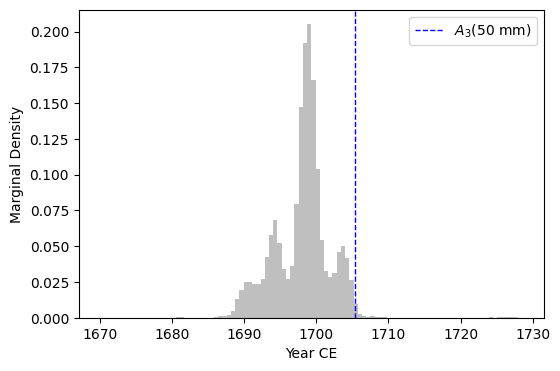

In [40]:
# index = 25
# interesting_depth = index * data["dc"]
# CV_values = data["th"] - data["dc"] * np.sum(short_samples[:, :, :index], axis = 2)
# fig, ax = plt.subplots(figsize=(6, 4))
# # for i in range(hmc_config["nch"]):
# ax.hist(CV_values[0, :], bins = 100, color = "grey", label = f"chain {i}", alpha = 0.5, density = True)
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}_chain0.jpg")
# plt.show()
index = 25
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[-1][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color='blue', linestyle='--', linewidth = 1, label = r"$A_3$" + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
# plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
# plt.show()

In [29]:
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[0,:,0])

# for i in range(hmc_config["nch"]):
#     lines = np.stack(
#         [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
#     )

#     lc = LineCollection(
#         lines,
#         colors=colors[i],
#         linewidths=1,
#         alpha=0.02,
#         label = f"Chain {i}"
#     )
#     ax.add_collection(lc)
#     ax.autoscale()
    
# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)

# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# # del model_ages, cumulative_sums, age_offsets, zeros, short_samples
# # gc.collect()

In [30]:
# index = 25
# interesting_depth = index * data["dc"]
# colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))

# CV_values = data["th"] - data["dc"] * np.sum(short_resampled_samples[:, :, :index], axis = 2)
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
# plt.savefig(f"{output_dir}/resampling_along_depth_{interesting_depth}.jpg")
# plt.show()

In [31]:

# # Age depth trace plot
# cumulative_sums = np.cumsum(short_resampled_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_resampled_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets
# num_samples = len(short_resampled_samples[0,:,0])
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     lines = np.stack(
#         [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
#     )

#     lc = LineCollection(
#         lines,
#         colors=colors[i],
#         linewidths=1,
#         alpha=0.02,
#         label = f"Chain {i}"
#     )
#     ax.add_collection(lc)
#     ax.autoscale()

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_try.jpg")
# plt.show()
# # del model_ages, cumulative_sums, age_offsets, zeros
# # gc.collect()

In [32]:
# data_path = f"../../../../data/inputdata_260219A"
# true_sample = np.load(f"{data_path}/true_sample.npy")
# true_age = np.hstack([np.array([data["th"]]), data["th"] - data["dc"] * np.cumsum(true_sample)])
# print(data_path)

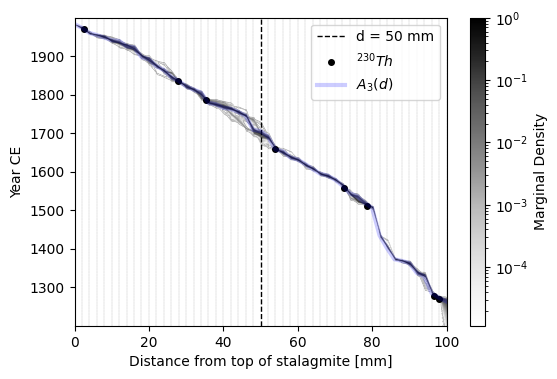

11873

In [33]:
from matplotlib import colors

chain = -1
X = resampled_samples[chain][:, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'
depth = np.arange(0, 2 * D + 1, 2)

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(1200, 2000 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, 2 * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, depth, norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = 'blue', linewidth=3, alpha = 0.2, label = r"$A_3(d)$")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean_{chain}.jpg")
plt.show()

del A, C
gc.collect()


In [34]:
# from matplotlib import colors

# chain = 4
# X = short_samples[chain].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'blue', linewidth=3, alpha = 0.2, label = r"$A_3(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/samples_no_mean_{chain}.jpg")
# plt.show()

In [35]:
# print(np.shape(true_age[:, None] - age))
# print(np.shape(age))
# print(np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0)))
# best_sol = age[:, np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0))]
# print(best_sol)
# print(np.linalg.norm(true_age[:, None] - age, axis = 0)[np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0))])

In [36]:
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(data["cs"], best_sol, color = "green", linewidth = 3, alpha = 0.5, label = "best solution")
# ax.plot(data["cs"], true_age, color = "black", linewidth = 3, alpha = 0.5, label = "true solution")
# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/best_sol.jpg")
# plt.show()


In [37]:
# plt.figure()
# plt.plot(data["cs"], best_sol - true_age)
# plt.xlabel("d [mm]")
# plt.ylabel(r"$\Delta A(d)$ [yr]")
# plt.show()

In [38]:
# del model_ages
# gc.collect()